# 📊 Exploratory Data Analysis (EDA)
## Real Estate Valuation Dataset

Comprehensive analysis of 12,814 real estate properties from Supabase

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import warnings

warnings.filterwarnings('ignore')

# Add the repo root (the folder that contains pipeline/)
for parent in [Path.cwd(), *Path.cwd().parents]:
    if (parent / 'pipeline').exists():
        sys.path.insert(0, str(parent))
        break
from pipeline.supabase_handler import fetch_csv_from_supabase

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
%matplotlib inline

print('✅ Imports successful!')

✅ Imports successful!


## 1. Load Data from Supabase

In [2]:
print('Loading raw data from Supabase...')
df = fetch_csv_from_supabase()
print(f'✅ Loaded {len(df)} raw records')
print(f'Shape: {df.shape}')
print(f'\nColumns: {list(df.columns)}')

cleaned_candidates = [
    Path('data/processed/model_ready_data.csv'),
    Path('data/processed/alonhadat_features_cleaned.csv'),
    Path('data/processed/alonhadat_cleaned.csv'),
]
for candidate in cleaned_candidates:
    if candidate.exists():
        cleaned_df = pd.read_csv(candidate)
        print(f'✅ Loaded cleaned data from {candidate}')
        print(f'   Cleaned shape: {cleaned_df.shape}')
        break
else:
    cleaned_df = None
    print('ℹ️ No cleaned/model-ready CSV found yet')

df.head()


Loading raw data from Supabase...
[Supabase] Fetching data from table: Raw_Features
[Supabase] Fetched 12814 rows from Raw_Features

✅ Loaded 12814 raw records
Shape: (12814, 46)

Columns: ['link', 'title', 'post_day', 'street', 'old_address', 'locality', 'region', 'listing_id', 'direction', 'listing_type', 'property_type', 'legal_status', 'num_floors', 'num_bedrooms', 'road_width_m', 'width_m', 'length_m', 'price_vnd', 'area_m2', 'dining_room_bin', 'kitchen_bin', 'terrace_bin', 'car_parking_bin', 'owner_listing_bin', 'locality_square', 'locality_population_density', 'lat', 'lon', 'matched_address', 'distance_to_center_km', 'nearest_school_km', 'school_count_3km', 'nearest_hospital_km', 'hospital_count_5km', 'nearest_marketplace_km', 'marketplace_count_3km', 'nearest_supermarket_km', 'supermarket_count_3km', 'nearest_mall_km', 'mall_count_3km', 'nearest_bus_stop_km', 'bus_stop_count_1km', 'nearest_metro_km', 'metro_count_5km', 'description', 'created_at']
ℹ️ No cleaned/model-ready CSV 

,link,title,post_day,street,old_address,locality,region,listing_id,direction,listing_type,...,nearest_supermarket_km,supermarket_count_3km,nearest_mall_km,mall_count_3km,nearest_bus_stop_km,bus_stop_count_1km,nearest_metro_km,metro_count_5km,description,created_at
0,https://alonhadat.com.vn/ban-nha-rieng-hem-xe-...,Bán nhà riêng hẻm xe hơi 4 tầng mới đẹp lung l...,2026-05-23,đường lê quang định,"Đường Lê Quang Định, Phường 14, Quận Bình Thạn...",phường bình thạnh,hồ chí minh,18269430.0,unknown,can_ban,...,0.127429,61,3.067850,0,0.108269,47,2.080087,7,None,2026-07-18T11:11:29.232203+00:00
1,https://alonhadat.com.vn/sieu-vi-tri-toa-nha-h...,SIÊU VỊ TRÍ TÒA NHÀ HẦM 10 TẦNG LÊ THÁNH TÔN-Q...,2026-05-27,đường lê thánh tôn,"Đường Lê Thánh Tôn, Phường Bến Nghé, Quận 1, H...",phường sài gòn,hồ chí minh,17891053.0,unknown,can_ban,...,0.331273,97,0.690744,15,0.089534,68,0.352320,7,None,2026-07-18T11:11:29.232203+00:00
2,https://alonhadat.com.vn/ban-gap-nha-4-tang-ng...,"BÁN GẤP NHÀ 4 TẦNG NGANG KHỦNG 4,8M – TRẦN QUA...",2026-06-30,đường trần quang diệu,"Đường Trần Quang Diệu, Phường 14, Quận 3, Hồ C...",phường nhiêu lộc,hồ chí minh,18843030.0,unknown,can_ban,...,0.293004,108,0.833065,16,0.144080,55,2.531594,4,None,2026-07-18T11:11:29.232203+00:00
3,https://alonhadat.com.vn/4x11-nha-co-2-lau-moi...,"4x11, nhà có 2 lầu mới đường số 3, giáp Thạch LAM",2026-06-30,đường số 3,"Đường Số 3, Phường Bình Hưng Hòa A, Quận Bình ...",phường bình hưng hòa,hồ chí minh,18614772.0,unknown,can_ban,...,1.674035,14,1.509740,1,0.521155,15,NaN,0,None,2026-07-18T11:11:29.232203+00:00
4,https://alonhadat.com.vn/ban-biet-thu-khu-comp...,Bán Biệt Thự Khu Compound 284 Nguyễn Trọng Tuy...,2026-05-27,đường nguyễn trọng tuyển,"Đường Nguyễn Trọng Tuyển, Phường 10, Quận Phú ...",phường phú nhuận,hồ chí minh,16693368.0,unknown,can_ban,...,0.256364,53,1.945490,6,0.155312,47,3.900285,4,None,2026-07-18T11:11:29.232203+00:00


## 2. Data Overview

In [3]:
print('Data Types:')
print(df.dtypes)
print('\n' + '='*60)
print('Missing Values:')
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': missing[missing > 0].index,
    'Count': missing[missing > 0].values,
    'Percentage': missing_pct[missing_pct > 0].values
})
print(missing_df.to_string(index=False))

Data Types:
link                            object
title                           object
post_day                        object
street                          object
old_address                     object
locality                        object
region                          object
listing_id                     float64
direction                       object
listing_type                    object
property_type                   object
legal_status                    object
num_floors                     float64
num_bedrooms                   float64
road_width_m                   float64
width_m                        float64
length_m                       float64
price_vnd                      float64
area_m2                        float64
dining_room_bin                 object
kitchen_bin                     object
terrace_bin                     object
car_parking_bin                 object
owner_listing_bin               object
locality_square                 object
locality_popu

## 3. Price Analysis

In [4]:
print('\n📈 PRICE STATISTICS:')
print(df['price_vnd'].describe())
print(f'\nPrice range: {df["price_vnd"].min():,.0f} - {df["price_vnd"].max():,.0f} VND')
print(f'Median price: {df["price_vnd"].median():,.0f} VND')


📈 PRICE STATISTICS:
count    1.277600e+04
mean     3.702854e+10
std      8.242245e+10
min      4.800000e+01
25%      7.300000e+09
50%      1.450000e+10
75%      3.550000e+10
max      2.100000e+12
Name: price_vnd, dtype: float64

Price range: 48 - 2,100,000,000,000 VND
Median price: 14,500,000,000 VND


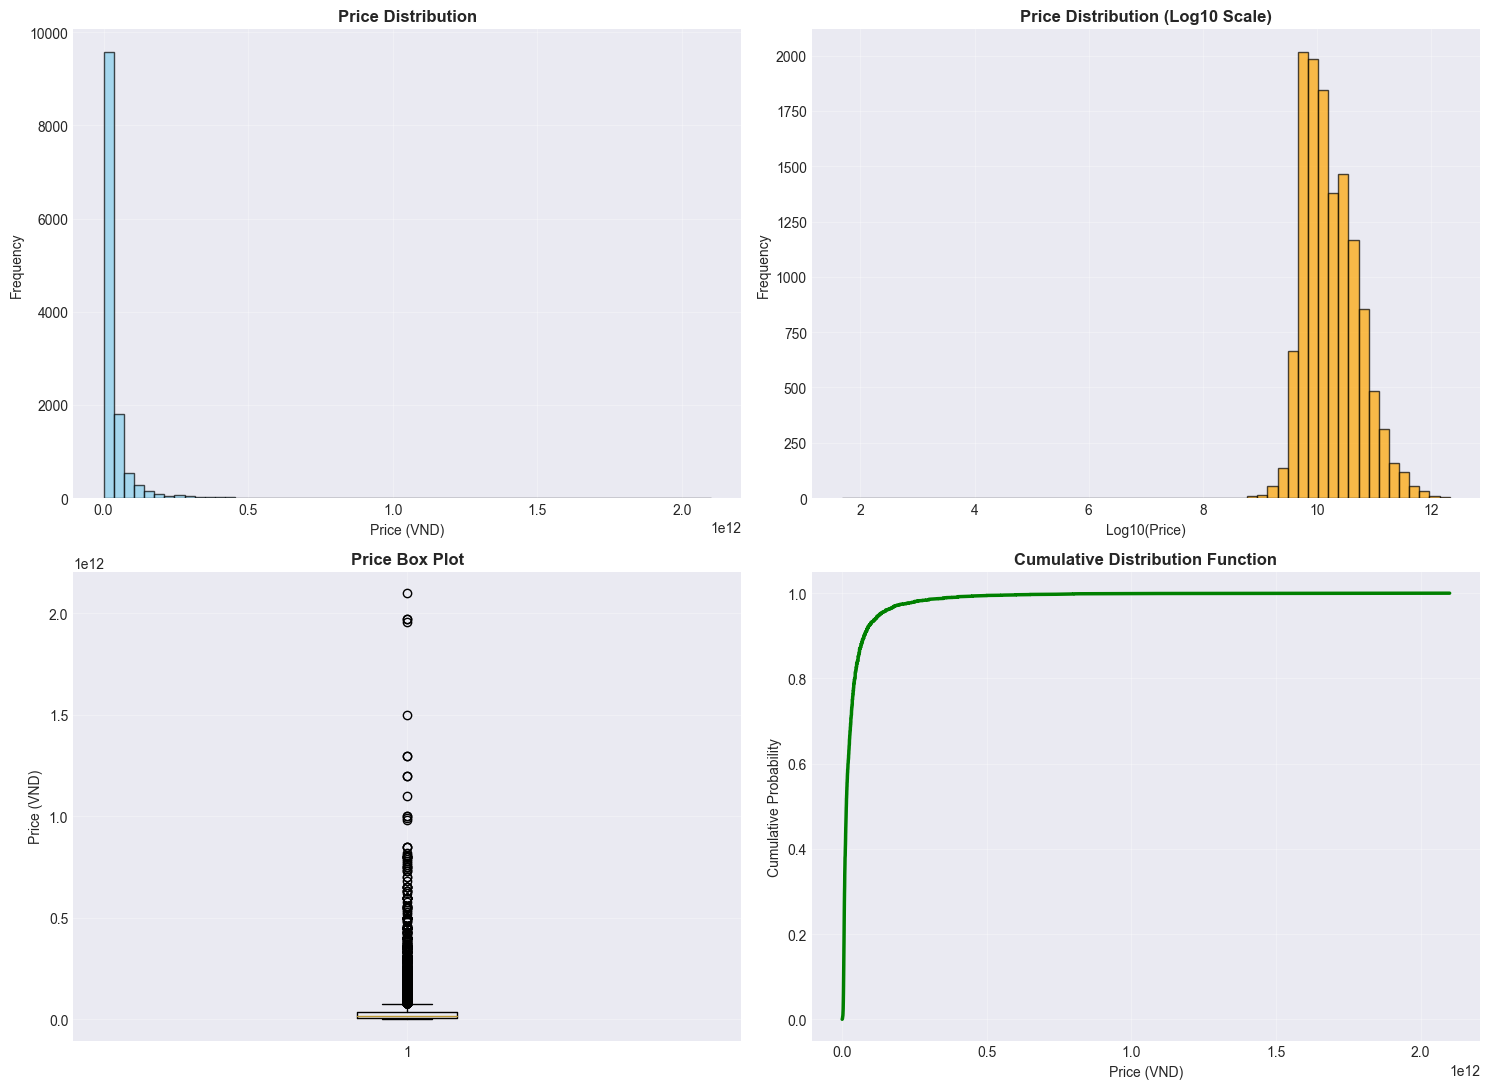

✅ Saved: 01_price_distribution.png


In [5]:
# Price distribution visualization
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Histogram
axes[0, 0].hist(df['price_vnd'].dropna(), bins=60, edgecolor='black', color='skyblue', alpha=0.7)
axes[0, 0].set_title('Price Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Price (VND)')
axes[0, 0].set_ylabel('Frequency')
axes[0, 0].grid(alpha=0.3)

# Log scale
axes[0, 1].hist(np.log10(df['price_vnd'].dropna()), bins=60, edgecolor='black', color='orange', alpha=0.7)
axes[0, 1].set_title('Price Distribution (Log10 Scale)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Log10(Price)')
axes[0, 1].set_ylabel('Frequency')
axes[0, 1].grid(alpha=0.3)

# Boxplot
axes[1, 0].boxplot(df['price_vnd'].dropna(), vert=True)
axes[1, 0].set_title('Price Box Plot', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Price (VND)')
axes[1, 0].grid(alpha=0.3)

# CDF
sorted_price = np.sort(df['price_vnd'].dropna())
cdf = np.arange(1, len(sorted_price) + 1) / len(sorted_price)
axes[1, 1].plot(sorted_price, cdf, linewidth=2.5, color='green')
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Price (VND)')
axes[1, 1].set_ylabel('Cumulative Probability')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('output/01_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 01_price_distribution.png')

## 4. Feature Correlation Analysis

In [6]:
# Select numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_df = df[numeric_cols].copy()
numeric_df = numeric_df.replace({np.inf: np.nan, -np.inf: np.nan})

# Correlation with price
correlations = numeric_df.corr()['price_vnd'].sort_values(ascending=False)
print('\n📊 TOP 20 CORRELATED FEATURES WITH PRICE:')
print(correlations.head(20))


📊 TOP 20 CORRELATED FEATURES WITH PRICE:
price_vnd                      1.000000
area_m2                        0.479661
width_m                        0.426778
road_width_m                   0.339347
num_bedrooms                   0.267503
supermarket_count_3km          0.244388
bus_stop_count_1km             0.226744
num_floors                     0.225704
mall_count_3km                 0.219463
metro_count_5km                0.212791
hospital_count_5km             0.166608
length_m                       0.161186
lon                            0.131667
marketplace_count_3km          0.128362
school_count_3km               0.124447
locality_population_density    0.034039
lat                           -0.003391
nearest_school_km             -0.038696
nearest_marketplace_km        -0.044927
distance_to_center_km         -0.075819
Name: price_vnd, dtype: float64


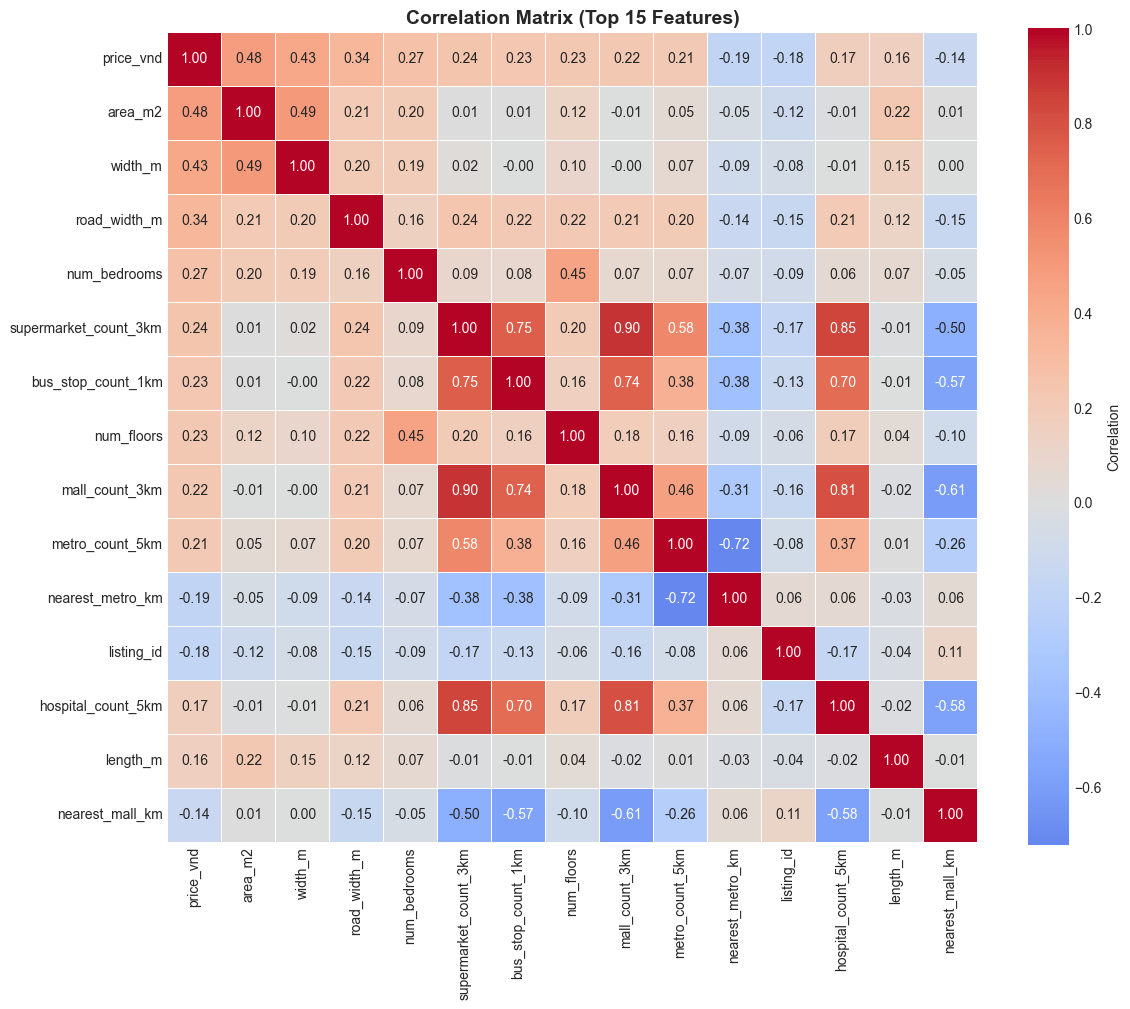

✅ Saved: 02_correlation_heatmap.png


In [7]:
# Correlation heatmap
top_features = correlations.abs().nlargest(15).index.tolist()

fig, ax = plt.subplots(figsize=(12, 10))
corr_matrix = numeric_df[top_features].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, ax=ax, cbar_kws={'label': 'Correlation'},
            square=True, linewidths=0.5)
ax.set_title('Correlation Matrix (Top 15 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('output/02_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 02_correlation_heatmap.png')

## 5. Geographic Analysis - Price Heatmap

In [8]:
# Filter valid geographic data
valid_geo = df.dropna(subset=['lat', 'lon', 'price_vnd'])
print(f'\n📍 Geographic Analysis:')
print(f'Valid records with coordinates: {len(valid_geo)}')
print(f'Latitude range: {valid_geo["lat"].min():.4f} - {valid_geo["lat"].max():.4f}')
print(f'Longitude range: {valid_geo["lon"].min():.4f} - {valid_geo["lon"].max():.4f}')


📍 Geographic Analysis:
Valid records with coordinates: 12776
Latitude range: 10.3447 - 11.1725
Longitude range: 106.4347 - 107.1730


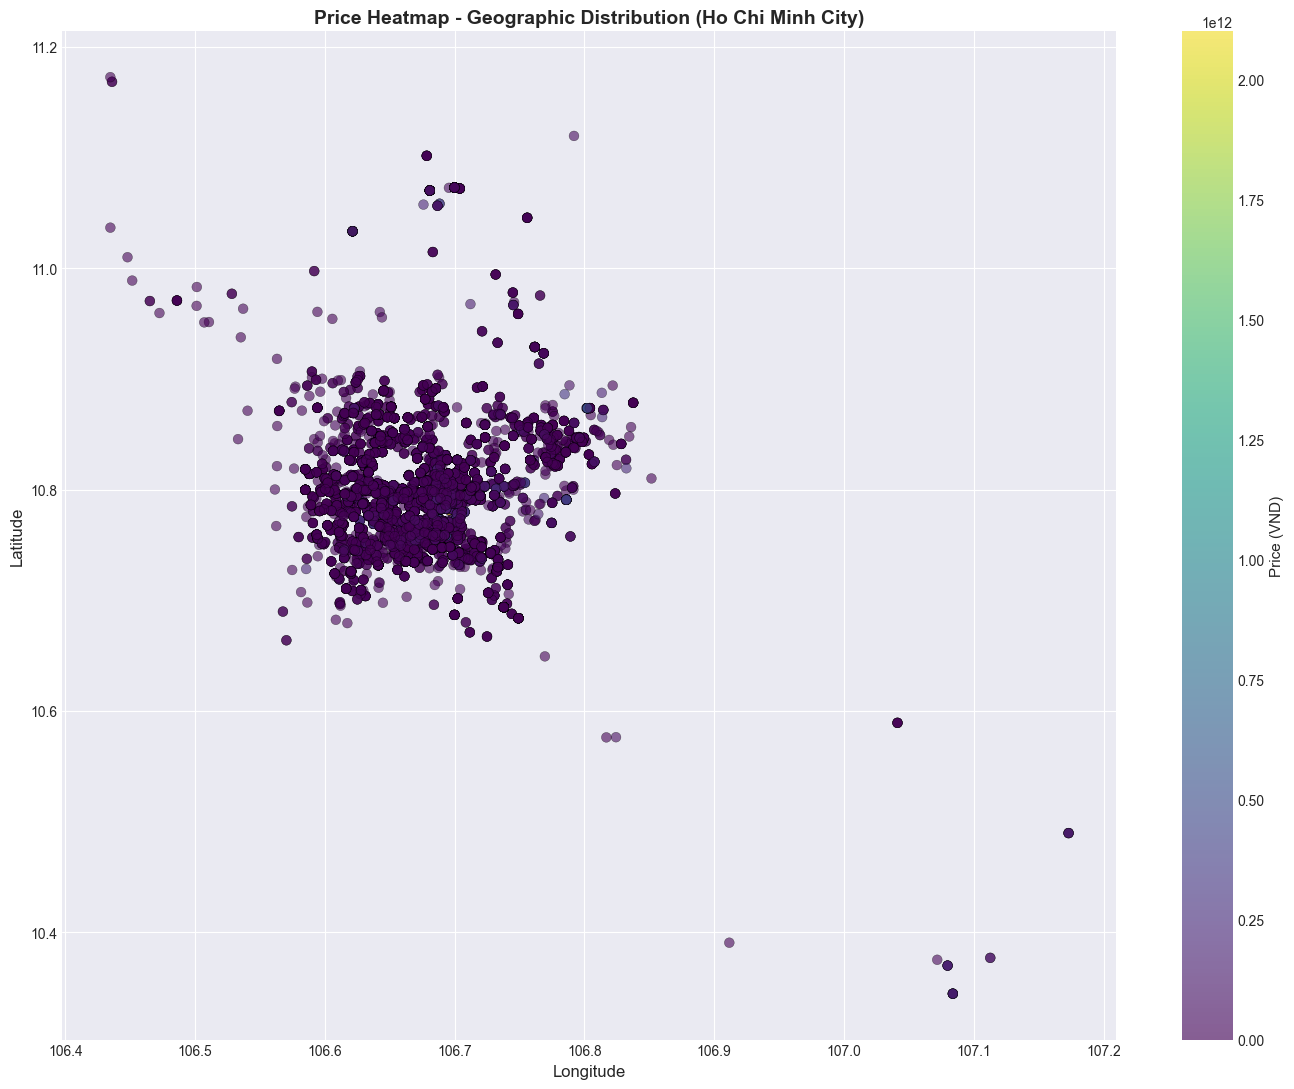

✅ Saved: 03_price_heatmap.png


In [9]:
# Price heatmap
fig, ax = plt.subplots(figsize=(14, 11))
scatter = ax.scatter(valid_geo['lon'], valid_geo['lat'],
                    c=valid_geo['price_vnd'], cmap='viridis',
                    s=50, alpha=0.6, edgecolors='black', linewidth=0.3)
ax.set_xlabel('Longitude', fontsize=12)
ax.set_ylabel('Latitude', fontsize=12)
ax.set_title('Price Heatmap - Geographic Distribution (Ho Chi Minh City)', 
            fontsize=14, fontweight='bold')
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label('Price (VND)', fontsize=11)
plt.tight_layout()
plt.savefig('output/03_price_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 03_price_heatmap.png')

## 6. Feature Distribution Analysis

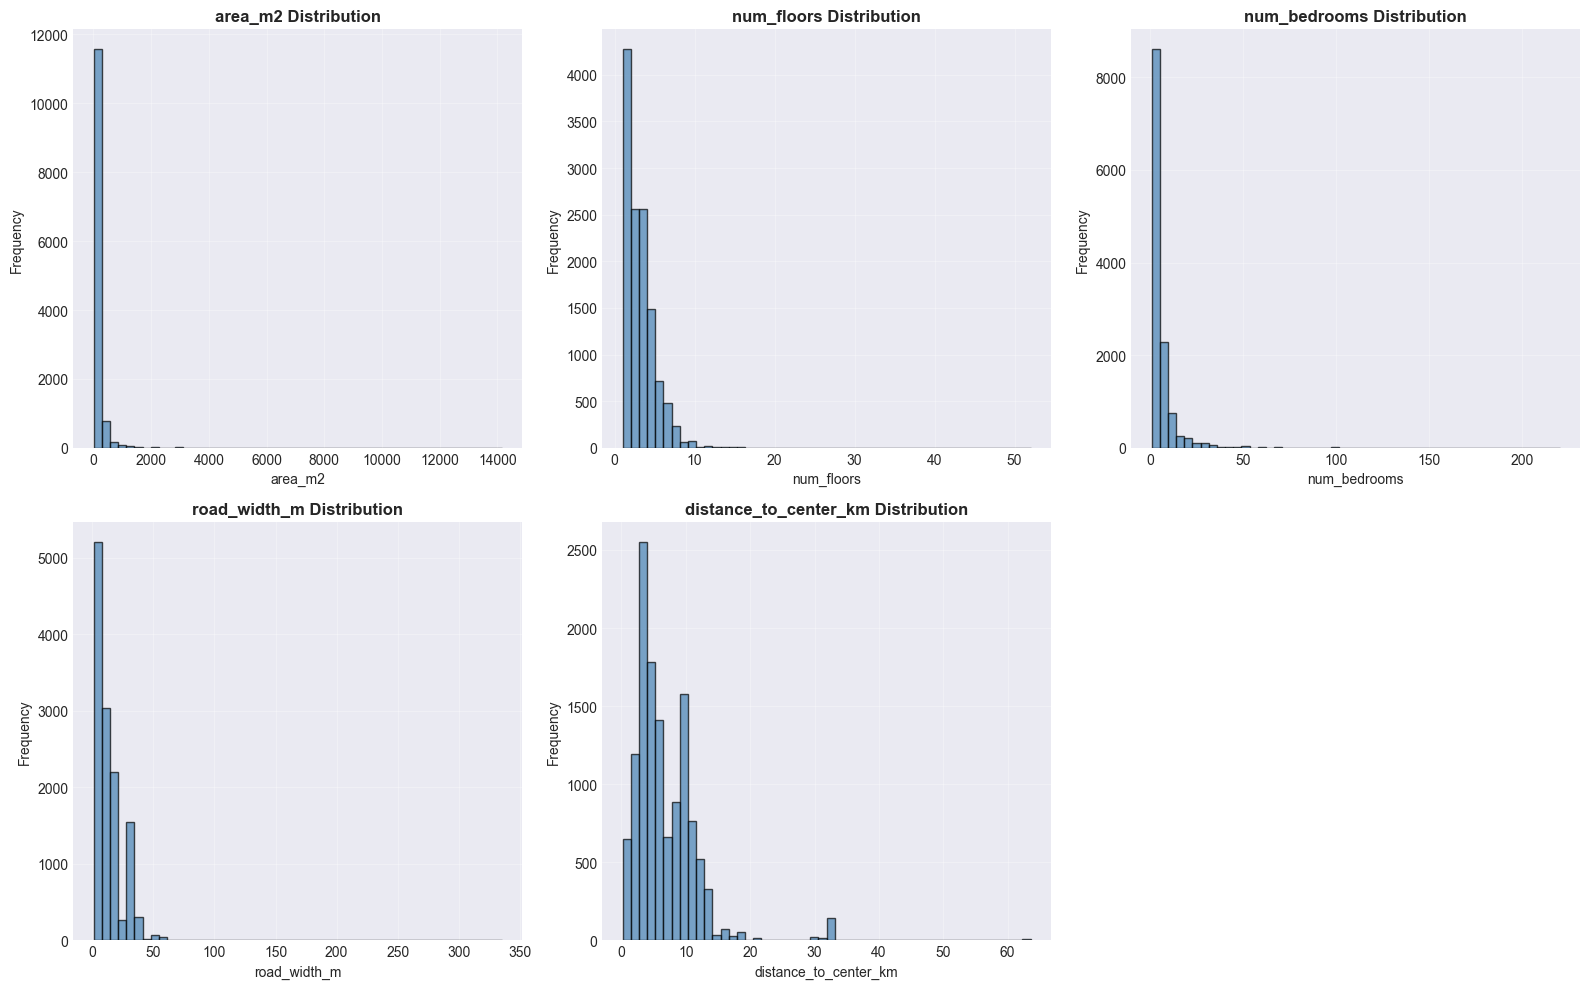

✅ Saved: 04_feature_distributions.png


In [10]:
# Key features distributions
key_features = ['area_m2', 'num_floors', 'num_bedrooms', 'road_width_m', 'distance_to_center_km']
existing_features = [f for f in key_features if f in df.columns]

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(existing_features):
    axes[idx].hist(df[feature].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    axes[idx].set_title(f'{feature} Distribution', fontweight='bold')
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)

# Hide unused subplots
for idx in range(len(existing_features), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig('output/04_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 04_feature_distributions.png')

## 7. POI Features Analysis

In [11]:
# POI features
poi_features = [f for f in df.columns if 'count' in f.lower()]
print(f'\n📍 POI FEATURES STATISTICS:')
for feature in poi_features[:8]:  # Show first 8
    print(f'{feature}: mean={df[feature].mean():.2f}, max={df[feature].max():.0f}')


📍 POI FEATURES STATISTICS:
school_count_3km: mean=104.46, max=226
hospital_count_5km: mean=43.37, max=92
marketplace_count_3km: mean=20.60, max=61
supermarket_count_3km: mean=39.49, max=117
mall_count_3km: mean=6.04, max=21
bus_stop_count_1km: mean=39.77, max=118
metro_count_5km: mean=2.51, max=10


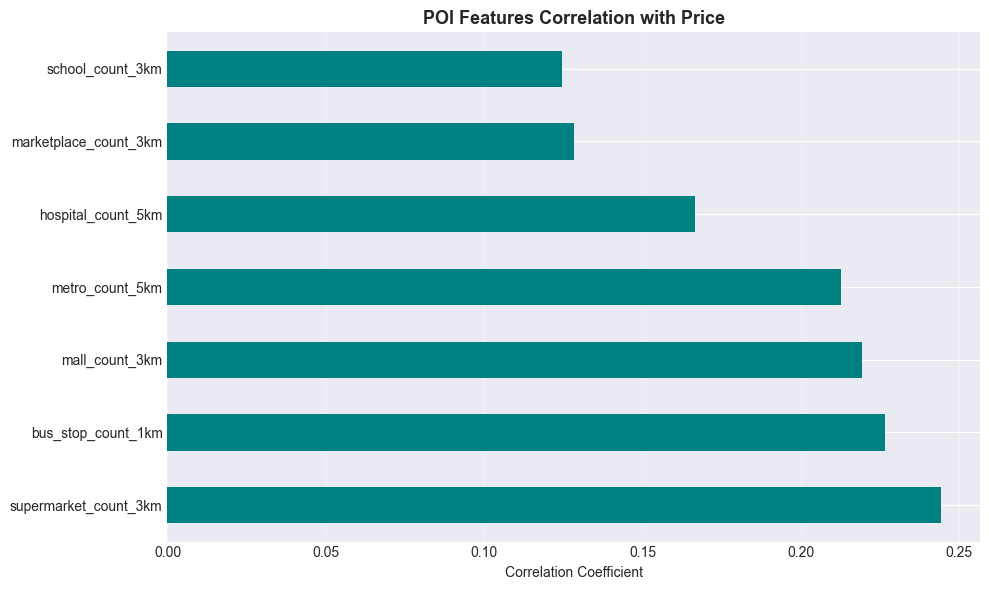

✅ Saved: 05_poi_correlation.png


In [12]:
# POI correlation with price
poi_count_features = [f for f in df.columns if 'count' in f.lower()]
poi_corr = df[poi_count_features + ['price_vnd']].corr()['price_vnd'].sort_values(ascending=False)[1:]

fig, ax = plt.subplots(figsize=(10, 6))
poi_corr.plot(kind='barh', ax=ax, color='teal')
ax.set_title('POI Features Correlation with Price', fontsize=13, fontweight='bold')
ax.set_xlabel('Correlation Coefficient')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('output/05_poi_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Saved: 05_poi_correlation.png')

## 8. Summary Statistics

In [13]:
# Create feature summary
feature_summary = pd.DataFrame({
    'Column': numeric_cols,
    'Missing': [df[col].isnull().sum() for col in numeric_cols],
    'Type': [df[col].dtype for col in numeric_cols],
    'Mean': [df[col].mean() for col in numeric_cols],
    'Std': [df[col].std() for col in numeric_cols],
    'Min': [df[col].min() for col in numeric_cols],
    'Max': [df[col].max() for col in numeric_cols]
})

feature_summary.to_csv('output/feature_summary.csv', index=False)
print('\n📊 Feature Summary:')
print(feature_summary.to_string(index=False))
print('\n✅ Saved: feature_summary.csv')


📊 Feature Summary:
                     Column  Missing    Type         Mean          Std          Min          Max
                 listing_id       38 float64 1.779780e+07 1.565895e+06 2.550086e+06 1.891493e+07
                 num_floors      288 float64 3.538959e+00 2.091337e+00 1.000000e+00 5.200000e+01
               num_bedrooms      229 float64 6.553119e+00 1.012510e+01 1.000000e+00 2.200000e+02
               road_width_m       61 float64 1.362366e+01 1.292100e+01 1.000000e+00 3.350000e+02
                    width_m     1282 float64 6.692349e+00 6.914712e+00 1.000000e+00 4.250000e+02
                   length_m     1686 float64 1.999787e+01 3.016286e+01 1.000000e+00 2.525000e+03
                  price_vnd       38 float64 3.702854e+10 8.242245e+10 4.800000e+01 2.100000e+12
                    area_m2       38 float64 1.671365e+02 4.147101e+02 6.000000e+00 1.414200e+04
locality_population_density       48 float64 3.227846e+01 1.837881e+01 1.166000e+00 7.990000e+02
          

## 9. Key Insights & Conclusions

In [14]:
print("\n" + "="*70)
print("✅ EDA COMPLETE - KEY INSIGHTS")
print("="*70)
print(f"""
📊 DATASET OVERVIEW:
  • Total records: {len(df):,}
  • Features: {len(df.columns)}
  • Missing values: {df.isnull().sum().sum():,}

💰 PRICE ANALYSIS:
  • Mean price: {df['price_vnd'].mean():,.0f} VND
  • Median price: {df['price_vnd'].median():,.0f} VND
  • Price std dev: {df['price_vnd'].std():,.0f} VND
  • Range: {df['price_vnd'].min():,.0f} - {df['price_vnd'].max():,.0f} VND

🎯 TOP PREDICTIVE FEATURES:
  1. Area (area_m2): {correlations['area_m2']:.3f}
  2. Width (width_m): {correlations['width_m']:.3f}
  3. Road width (road_width_m): {correlations['road_width_m']:.3f}
  4. Bedrooms (num_bedrooms): {correlations['num_bedrooms']:.3f}
  5. Supermarket count (supermarket_count_3km): {correlations['supermarket_count_3km']:.3f}

📍 GEOGRAPHIC DISTRIBUTION:
  • Valid coordinates: {len(valid_geo):,} properties
  • Average distance to center: {df['distance_to_center_km'].mean():.2f} km

⚠️  DATA QUALITY NOTES:
  • High missing values: width_m (1282), length_m (1686), nearest_metro_km (5605)
  • Consider handling outliers in price and area fields
  • Geographic clustering in Ho Chi Minh City

➡️  NEXT STEPS:
  1. Feature engineering & preprocessing
  2. Train ML model (target: MAPE < 10%)
  3. Model evaluation on test set
  4. Build BI dashboard
  5. Deploy web application
""")
print("="*70)


✅ EDA COMPLETE - KEY INSIGHTS

📊 DATASET OVERVIEW:
  • Total records: 12,814
  • Features: 46
  • Missing values: 19,589

💰 PRICE ANALYSIS:
  • Mean price: 37,028,541,938 VND
  • Median price: 14,500,000,000 VND
  • Price std dev: 82,422,452,440 VND
  • Range: 48 - 2,100,000,000,000 VND

🎯 TOP PREDICTIVE FEATURES:
  1. Area (area_m2): 0.480
  2. Width (width_m): 0.427
  3. Road width (road_width_m): 0.339
  4. Bedrooms (num_bedrooms): 0.268
  5. Supermarket count (supermarket_count_3km): 0.244

📍 GEOGRAPHIC DISTRIBUTION:
  • Valid coordinates: 12,776 properties
  • Average distance to center: 6.77 km

⚠️  DATA QUALITY NOTES:
  • High missing values: width_m (1282), length_m (1686), nearest_metro_km (5605)
  • Consider handling outliers in price and area fields
  • Geographic clustering in Ho Chi Minh City

➡️  NEXT STEPS:
  1. Feature engineering & preprocessing
  2. Train ML model (target: MAPE < 10%)
  3. Model evaluation on test set
  4. Build BI dashboard
  5. Deploy web applicati